# PM₂.₅ Forecasting with LSTM — Toronto Downtown Station

**Research Question:** How accurately can PM₂.₅ concentrations in Ontario be forecasted over **4-hour, 6-hour, and 24-hour** intervals using meteorological data?

**Organisation:** Toronto Transit Commission (TTC)  
**Model:** Multi-horizon Long Short-Term Memory (LSTM)  
**Input:** 24-hour lookback window of weather + air-quality features  
**Outputs:** Predicted PM₂.₅ at +4 h, +6 h, and +24 h

---

## Notebook Structure
1. Imports & device setup
2. Data loading & EDA
3. Feature engineering (cyclic time encoding, NaN handling, scaling)
4. Sliding-window dataset (multi-horizon)
5. LSTM model architecture
6. Training loop (with wall-clock timing)
7. Evaluation — RMSE, MAE, R² per horizon
8. Save & load model
9. Visualisation

## 1  —  Imports & Device Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')      # Apple Silicon GPU
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

Using device: mps


## 2  —  Data Loading & EDA

In [2]:
DATA_PATH = '../data/data_clean/cleaned_data_toronto_downtown.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print(f'Shape         : {df.shape}')
print(f'Date range    : {df["Datetime"].min()}  →  {df["Datetime"].max()}')
print(f'PM₂.₅ missing : {df["PM_ppb"].isna().sum()} rows ({df["PM_ppb"].isna().mean()*100:.1f}%)')
print('\nSummary statistics for key columns:')
display(df[['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)',
            'Precip. Amount (mm)', 'Stn Press (kPa)', 'Visibility (km)']].describe().round(2))

Shape         : (35064, 35)
Date range    : 2022-01-01 00:00:00  →  2025-12-31 23:00:00
PM₂.₅ missing : 829 rows (2.4%)

Summary statistics for key columns:


,PM_ppb,Temp (°C),Rel Hum (%),Wind Spd (km/h),Precip. Amount (mm),Stn Press (kPa),Visibility (km)
count,34235.00,34770.00,34585.00,34978.00,34993.00,34770.00,34980.00
mean,8.49,9.77,73.13,18.07,0.08,100.66,15.18
std,7.13,9.61,14.73,10.30,0.64,0.80,3.00
min,0.00,-20.00,16.00,0.00,0.00,96.89,0.00
25%,4.00,2.20,63.00,11.00,0.00,100.17,16.10
50%,7.00,9.30,74.00,17.00,0.00,100.68,16.10
75%,11.00,18.50,84.00,24.00,0.00,101.19,16.10
max,165.00,34.40,100.00,72.00,43.70,103.77,16.10


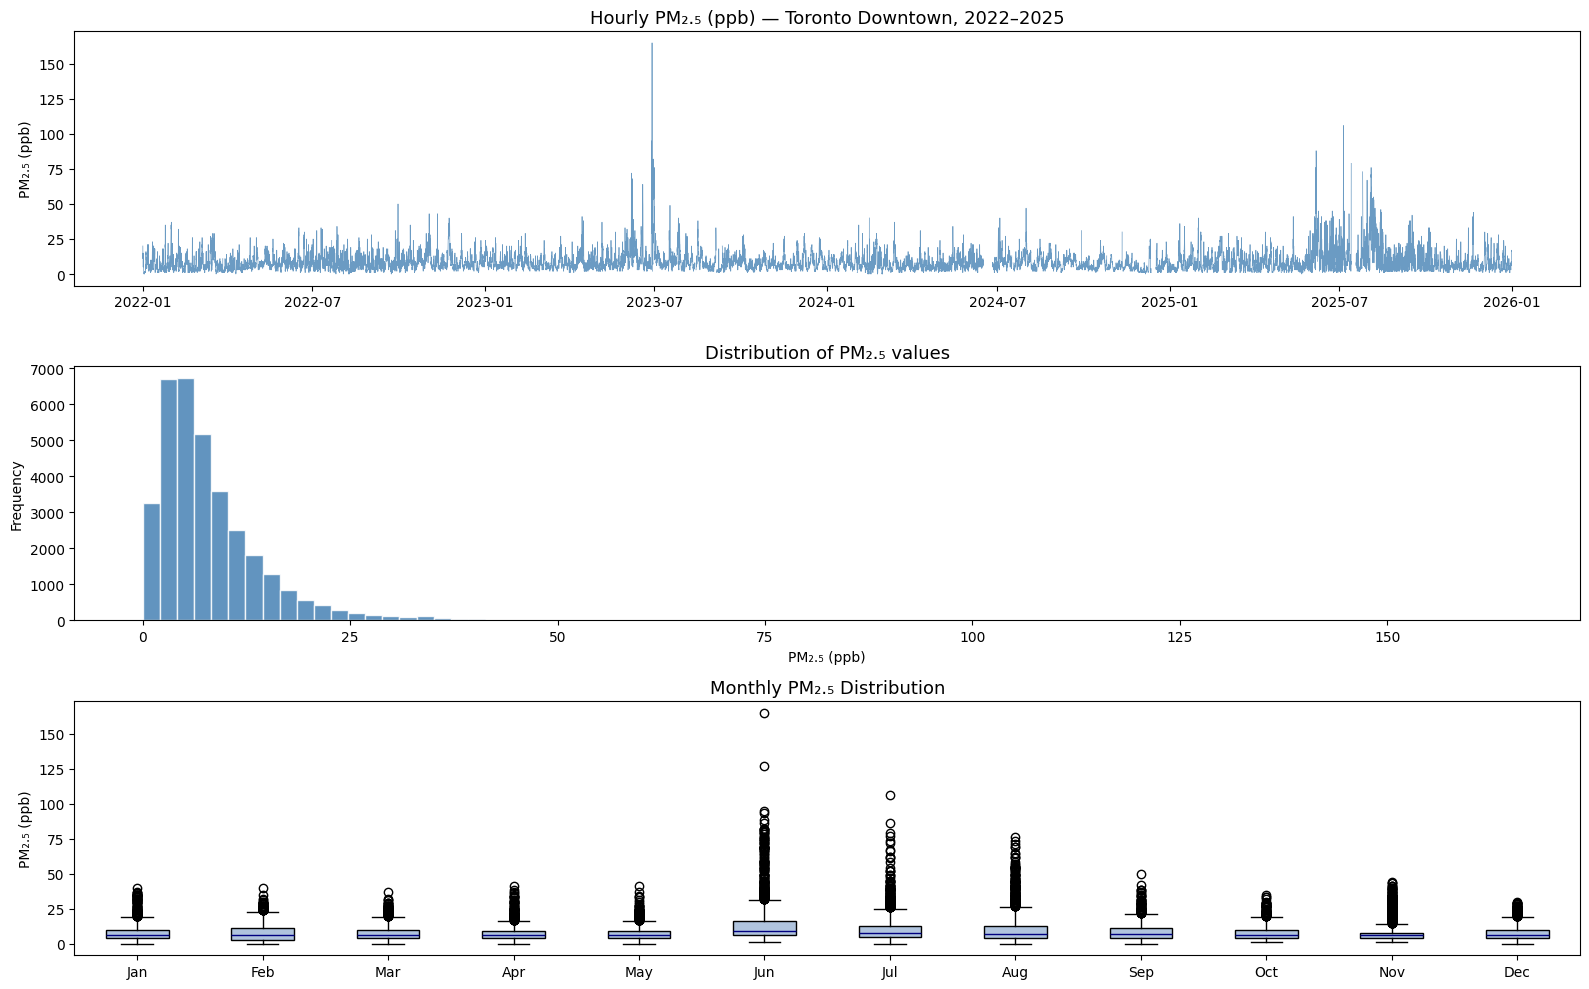

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

# PM2.5 time series
axes[0].plot(df['Datetime'], df['PM_ppb'], linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('Hourly PM₂.₅ (ppb) — Toronto Downtown, 2022–2025', fontsize=13)
axes[0].set_ylabel('PM₂.₅ (ppb)')

# Histogram of PM2.5
axes[1].hist(df['PM_ppb'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of PM₂.₅ values', fontsize=13)
axes[1].set_xlabel('PM₂.₅ (ppb)')
axes[1].set_ylabel('Frequency')

# Monthly box plots
df_plot = df.dropna(subset=['PM_ppb']).copy()
df_plot['Month'] = df_plot['Datetime'].dt.month
month_groups = [df_plot.loc[df_plot['Month'] == m, 'PM_ppb'].values for m in range(1, 13)]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].boxplot(month_groups, labels=month_labels, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'), medianprops=dict(color='navy'))
axes[2].set_title('Monthly PM₂.₅ Distribution', fontsize=13)
axes[2].set_ylabel('PM₂.₅ (ppb)')

plt.tight_layout()
plt.show()

## 3  —  Feature Engineering & Preprocessing

In [4]:
# ── Feature selection ─────────────────────────────────────────────────────────
WEATHER_FEATURES = [
    'Temp (°C)',
    'Dew Point Temp (°C)',
    'Rel Hum (%)',
    'Precip. Amount (mm)',
    'Wind Dir (10s deg)',
    'Wind Spd (km/h)',
    'Visibility (km)',
    'Stn Press (kPa)',
]

TARGET_COL = 'PM_ppb'

# ── Work on a copy ────────────────────────────────────────────────────────────
feat_df = df[['Datetime', TARGET_COL] + WEATHER_FEATURES].copy()

# ── Cyclic time encodings ─────────────────────────────────────────────────────
feat_df['hour_sin']    = np.sin(2 * np.pi * feat_df['Datetime'].dt.hour   / 24)
feat_df['hour_cos']    = np.cos(2 * np.pi * feat_df['Datetime'].dt.hour   / 24)
feat_df['month_sin']   = np.sin(2 * np.pi * feat_df['Datetime'].dt.month  / 12)
feat_df['month_cos']   = np.cos(2 * np.pi * feat_df['Datetime'].dt.month  / 12)
feat_df['dow_sin']     = np.sin(2 * np.pi * feat_df['Datetime'].dt.dayofweek / 7)
feat_df['dow_cos']     = np.cos(2 * np.pi * feat_df['Datetime'].dt.dayofweek / 7)

CYCLIC_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

ALL_FEATURES = WEATHER_FEATURES + CYCLIC_FEATURES  # model input features

print(f'Total input features : {len(ALL_FEATURES)}')
print(f'Feature list         : {ALL_FEATURES}')

Total input features : 14
Feature list         : ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


In [5]:
# ── Handle missing values ─────────────────────────────────────────────────────
# Forward-fill short gaps (≤ 3 consecutive hours), then drop remaining NaNs
feat_df[ALL_FEATURES + [TARGET_COL]] = (
    feat_df[ALL_FEATURES + [TARGET_COL]]
    .ffill(limit=3)
)

before = len(feat_df)
feat_df = feat_df.dropna(subset=ALL_FEATURES + [TARGET_COL]).reset_index(drop=True)
print(f'Rows before cleaning : {before}')
print(f'Rows after  cleaning : {len(feat_df)}')
print(f'Rows dropped         : {before - len(feat_df)}')

Rows before cleaning : 35064
Rows after  cleaning : 33989
Rows dropped         : 1075


In [6]:
# ── Chronological train / val / test split (70 / 15 / 15) ────────────────────
n = len(feat_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = feat_df.iloc[:train_end]
val_df   = feat_df.iloc[train_end:val_end]
test_df  = feat_df.iloc[val_end:]

print(f'Train : {len(train_df):>6,} rows  ({train_df["Datetime"].min().date()} → {train_df["Datetime"].max().date()})')
print(f'Val   : {len(val_df):>6,} rows  ({val_df["Datetime"].min().date()} → {val_df["Datetime"].max().date()})')
print(f'Test  : {len(test_df):>6,} rows  ({test_df["Datetime"].min().date()} → {test_df["Datetime"].max().date()})')

Train : 23,792 rows  (2022-01-01 → 2024-10-17)
Val   :  5,098 rows  (2024-10-17 → 2025-05-24)
Test  :  5,099 rows  (2025-05-24 → 2025-12-31)


In [7]:
# ── Standardise features (fit only on train to prevent data leakage) ──────────
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

train_X = feat_scaler.fit_transform(train_df[ALL_FEATURES].values)
val_X   = feat_scaler.transform(val_df[ALL_FEATURES].values)
test_X  = feat_scaler.transform(test_df[ALL_FEATURES].values)

train_y = target_scaler.fit_transform(train_df[[TARGET_COL]].values)   # shape (N, 1)
val_y   = target_scaler.transform(val_df[[TARGET_COL]].values)
test_y  = target_scaler.transform(test_df[[TARGET_COL]].values)

print('Scaling complete.')
print(f'Feature mean (train, first 3): {feat_scaler.mean_[:3].round(3)}')
print(f'Target mean (train): {target_scaler.mean_[0]:.3f}  std: {target_scaler.scale_[0]:.3f}')

Scaling complete.
Feature mean (train, first 3): [10.101  5.222 73.14 ]
Target mean (train): 8.244  std: 6.343


## 4  —  Sliding-Window Dataset (Multi-Horizon)

In [8]:
LOOKBACK   = 24                       # hours of history fed to the LSTM
HORIZONS   = [4, 6, 24]               # forecast horizons (hours ahead)
MAX_HORIZON = max(HORIZONS)
BATCH_SIZE = 128


class PM25Dataset(Dataset):
    """
    Sliding-window dataset for multi-horizon PM2.5 forecasting.

    Each sample:
        X : (LOOKBACK, n_features)  — input window
        y : (len(HORIZONS),)        — PM2.5 at t+4, t+6, t+24
    """

    def __init__(self, features: np.ndarray, targets: np.ndarray,
                 lookback: int, horizons: list[int]):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets.squeeze(), dtype=torch.float32)
        self.lookback  = lookback
        self.horizons  = horizons
        self.max_h     = max(horizons)

    def __len__(self):
        return len(self.features) - self.lookback - self.max_h + 1

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.lookback]                          # (L, F)
        y = torch.stack([
            self.targets[idx + self.lookback + h - 1] for h in self.horizons  # scalar per horizon
        ])                                                                      # (3,)
        return x, y


train_ds = PM25Dataset(train_X, train_y, LOOKBACK, HORIZONS)
val_ds   = PM25Dataset(val_X,   val_y,   LOOKBACK, HORIZONS)
test_ds  = PM25Dataset(test_X,  test_y,  LOOKBACK, HORIZONS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Lookback window  : {LOOKBACK} hours')
print(f'Forecast horizons: {HORIZONS} hours')
print(f'Train samples    : {len(train_ds):,}')
print(f'Val   samples    : {len(val_ds):,}')
print(f'Test  samples    : {len(test_ds):,}')

Lookback window  : 24 hours
Forecast horizons: [4, 6, 24] hours
Train samples    : 23,745
Val   samples    : 5,051
Test  samples    : 5,052


## 5  —  LSTM Model Architecture

In [9]:
class PM25LSTMForecaster(nn.Module):
    """
    Multi-horizon LSTM for PM2.5 forecasting.

    Architecture
    ─────────────
    Input  → (batch, seq_len, input_size)
    LSTM   → 2 stacked layers with dropout between them
    Last hidden state → shared FC trunk → 3 output heads (one per horizon)
    3 independent output heads (one per horizon)

    Parameters
    ──────────
    input_size  : number of input features
    hidden_size : LSTM hidden units per layer
    num_layers  : number of stacked LSTM layers
    dropout     : dropout probability (applied between LSTM layers and in trunk)
    n_horizons  : number of forecast horizons (default 3: 4h, 6h, 24h)
    """

    def __init__(
        self,
        input_size:  int,
        hidden_size: int  = 128,
        num_layers:  int  = 2,
        dropout:     float = 0.2,
        n_horizons:  int   = 3,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0.0,
            batch_first  = True,
        )

        # Shared fully-connected trunk
        self.fc_trunk = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # One output head per horizon
        self.heads = nn.ModuleList([
            nn.Linear(64, 1) for _ in range(n_horizons)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)             # (batch, seq_len, hidden_size)
        last_hidden = lstm_out[:, -1, :]       # take the final time-step
        trunk = self.fc_trunk(last_hidden)     # (batch, 64)
        preds = torch.cat(
            [head(trunk) for head in self.heads], dim=1
        )                                      # (batch, n_horizons)
        return preds


N_FEATURES = len(ALL_FEATURES)
model = PM25LSTMForecaster(
    input_size  = N_FEATURES,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.2,
    n_horizons  = len(HORIZONS),
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

PM25LSTMForecaster(
  (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc_trunk): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (heads): ModuleList(
    (0-2): 3 x Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 214,275


### Architecture Diagram

The diagram below shows the full data-flow through the model, from the 24-hour input window to the three independent forecast heads.

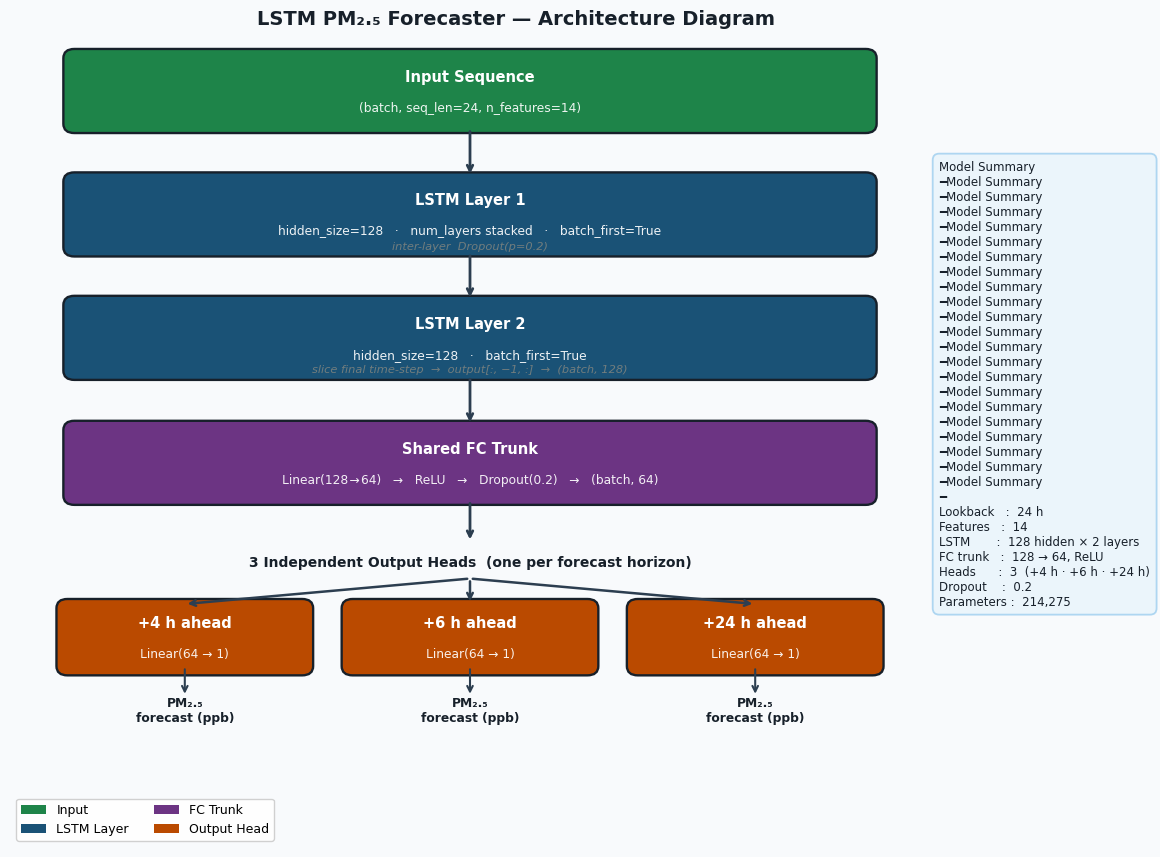

Saved → ../figures/lstm_architecture.png


In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(11, 9))
ax  = fig.add_axes([0.04, 0.04, 0.92, 0.90])
ax.set_xlim(0, 11)
ax.set_ylim(0, 10.5)
ax.axis('off')
fig.patch.set_facecolor('#F8FAFC')

C = dict(inp='#1E8449', lstm='#1A5276', fc='#6C3483',
         head='#BA4A00', text='#17202A', muted='#717D7E', arrow='#2C3E50')

def fbox(cx, cy, w, h, title, sub='', color='#1A5276'):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h, zorder=3,
                        boxstyle='round,pad=0.12', fc=color, ec='#17202A', lw=1.7)
    ax.add_patch(p)
    dy = 0.18 if sub else 0
    ax.text(cx, cy+dy, title, ha='center', va='center', fontsize=10.5,
            fontweight='bold', color='white', zorder=4)
    if sub:
        ax.text(cx, cy-0.22, sub, ha='center', va='center',
                fontsize=8.8, color='white', alpha=0.92, zorder=4)

def varr(x, y1, y2, note=''):
    ax.annotate('', xy=(x, y2+0.07), xytext=(x, y1-0.07),
                arrowprops=dict(arrowstyle='->', lw=2.0, color=C['arrow']), zorder=5)
    if note:
        ax.text(x+0.18, (y1+y2)/2, note, fontsize=8.2,
                color=C['muted'], style='italic', va='center')

CX = 5.0

# ── Layer boxes ──────────────────────────────────────────────────────────────
fbox(CX, 9.8,  8.6, 0.85, 'Input Sequence',
     '(batch, seq_len=24, n_features=14)', C['inp'])

varr(CX, 9.38, 8.62)

fbox(CX, 8.2,  8.6, 0.85, 'LSTM Layer 1',
     'hidden_size=128   ·   num_layers stacked   ·   batch_first=True', C['lstm'])

ax.text(CX, 7.75, 'inter-layer  Dropout(p=0.2)', ha='center',
        fontsize=8.2, color=C['muted'], style='italic')
varr(CX, 7.77, 7.02)

fbox(CX, 6.60, 8.6, 0.85, 'LSTM Layer 2',
     'hidden_size=128   ·   batch_first=True', C['lstm'])

ax.text(CX, 6.15, 'slice final time-step  →  output[:, \u22121, :]  →  (batch, 128)',
        ha='center', fontsize=8.2, color=C['muted'], style='italic')
varr(CX, 6.17, 5.40)

fbox(CX, 4.98, 8.6, 0.85, 'Shared FC Trunk',
     'Linear(128\u200a\u2192\u200a64)   \u2192   ReLU   \u2192   Dropout(0.2)   \u2192   (batch, 64)', C['fc'])

varr(CX, 4.56, 3.88)

# ── Split label ───────────────────────────────────────────────────────────────
ax.text(CX, 3.68, '3 Independent Output Heads  (one per forecast horizon)',
        ha='center', va='center', fontsize=10, fontweight='bold', color=C['text'])

HEAD_XS = [1.9, 5.0, 8.1]
HEAD_LBLS = ['+4 h ahead', '+6 h ahead', '+24 h ahead']

for hx in HEAD_XS:
    ax.annotate('', xy=(hx, 3.15), xytext=(CX, 3.48),
                arrowprops=dict(arrowstyle='->', lw=1.8, color=C['arrow']), zorder=5)

for hx, lbl in zip(HEAD_XS, HEAD_LBLS):
    fbox(hx, 2.72, 2.55, 0.75, lbl, 'Linear(64 \u2192 1)', C['head'])
    ax.annotate('', xy=(hx, 1.95), xytext=(hx, 2.34),
                arrowprops=dict(arrowstyle='->', lw=1.5, color=C['arrow']), zorder=5)
    ax.text(hx, 1.77, 'PM\u2082.\u2085\nforecast (ppb)',
            ha='center', va='center', fontsize=8.8, color=C['text'], fontweight='bold')

# ── Summary panel ─────────────────────────────────────────────────────────────
total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
summary = (
    "Model Summary\n"
    "\u2501" * 22 + "\n"
    f"Lookback   :  24 h\n"
    f"Features   :  {N_FEATURES}\n"
    "LSTM       :  128 hidden \u00d7 2 layers\n"
    "FC trunk   :  128 \u2192 64, ReLU\n"
    "Heads      :  3  (+4 h \u00b7 +6 h \u00b7 +24 h)\n"
    "Dropout    :  0.2\n"
    f"Parameters :  {total_p:,}"
)
ax.text(10.1, 6.0, summary, fontsize=8.5, va='center', ha='left',
        color=C['text'], clip_on=False,
        bbox=dict(boxstyle='round,pad=0.55', fc='#EBF5FB', ec='#AED6F1', lw=1.3))

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(fc=C['inp'],  label='Input'),
    mpatches.Patch(fc=C['lstm'], label='LSTM Layer'),
    mpatches.Patch(fc=C['fc'],   label='FC Trunk'),
    mpatches.Patch(fc=C['head'], label='Output Head'),
], loc='lower left', fontsize=9, framealpha=0.9, edgecolor='#ccc', ncol=2)

ax.set_title('LSTM PM\u2082.\u2085 Forecaster \u2014 Architecture Diagram',
             fontsize=14, fontweight='bold', color=C['text'], y=1.005)

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/lstm_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved \u2192 ../figures/lstm_architecture.png')

## 6  —  Training Loop

In [10]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS        = 50
LEARNING_RATE = 1e-3
PATIENCE      = 7        # early stopping patience (epochs)
MODEL_SAVE_PATH = '../models/lstm_pm25_best.pt'

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)


def run_epoch(loader, train: bool) -> float:
    """Run one epoch; return average loss."""
    model.train() if train else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)         # (batch, 3)
            if train:
                optimizer.zero_grad()
            preds = model(X_batch)               # (batch, 3)
            loss  = criterion(preds, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


# ── Training ──────────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss   = float('inf')
patience_counter = 0

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

print(f'Training on {DEVICE}  |  epochs={EPOCHS}  |  batch={BATCH_SIZE}  |  lr={LEARNING_RATE}')
print('─' * 65)

train_start = time.perf_counter()   # ← wall-clock timer start

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    epoch_time = time.perf_counter() - epoch_start
    print(f'Epoch {epoch:>3}/{EPOCHS}  |  '
          f'Train MSE: {tr_loss:.5f}  |  '
          f'Val MSE: {val_loss:.5f}  |  '
          f'{epoch_time:.1f}s')

    # ── Save best model ────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch'              : epoch,
            'model_state_dict'   : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'           : best_val_loss,
            'model_config'       : {
                'input_size'  : N_FEATURES,
                'hidden_size' : 128,
                'num_layers'  : 2,
                'dropout'     : 0.2,
                'n_horizons'  : len(HORIZONS),
            },
            'feature_names'      : ALL_FEATURES,
            'horizons'           : HORIZONS,
            'feat_scaler_mean'   : feat_scaler.mean_,
            'feat_scaler_scale'  : feat_scaler.scale_,
            'target_scaler_mean' : target_scaler.mean_,
            'target_scaler_scale': target_scaler.scale_,
        }, MODEL_SAVE_PATH)
        print(f'  ✓ New best model saved (val MSE = {best_val_loss:.5f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch} epochs (no improvement for {PATIENCE} epochs).')
            break

total_train_time = time.perf_counter() - train_start  # ← wall-clock timer end
print('─' * 65)
print(f'Total training time : {total_train_time:.1f}s  '
      f'({total_train_time/60:.2f} min)')
print(f'Best validation MSE : {best_val_loss:.5f}')
print(f'Model saved to      : {MODEL_SAVE_PATH}')

Training on mps  |  epochs=50  |  batch=128  |  lr=0.001
─────────────────────────────────────────────────────────────────
Epoch   1/50  |  Train MSE: 0.82063  |  Val MSE: 0.65834  |  5.1s
  ✓ New best model saved (val MSE = 0.65834)
Epoch   2/50  |  Train MSE: 0.69928  |  Val MSE: 0.71006  |  5.2s
Epoch   3/50  |  Train MSE: 0.58251  |  Val MSE: 0.71762  |  4.9s
Epoch   4/50  |  Train MSE: 0.49256  |  Val MSE: 0.78253  |  6.5s
Epoch   5/50  |  Train MSE: 0.42761  |  Val MSE: 0.76560  |  4.6s
Epoch   6/50  |  Train MSE: 0.34833  |  Val MSE: 0.76134  |  4.4s
Epoch   7/50  |  Train MSE: 0.30817  |  Val MSE: 0.78260  |  5.1s
Epoch   8/50  |  Train MSE: 0.29052  |  Val MSE: 0.80033  |  3.8s

Early stopping triggered after 8 epochs (no improvement for 7 epochs).
─────────────────────────────────────────────────────────────────
Total training time : 39.7s  (0.66 min)
Best validation MSE : 0.65834
Model saved to      : ../models/lstm_pm25_best.pt


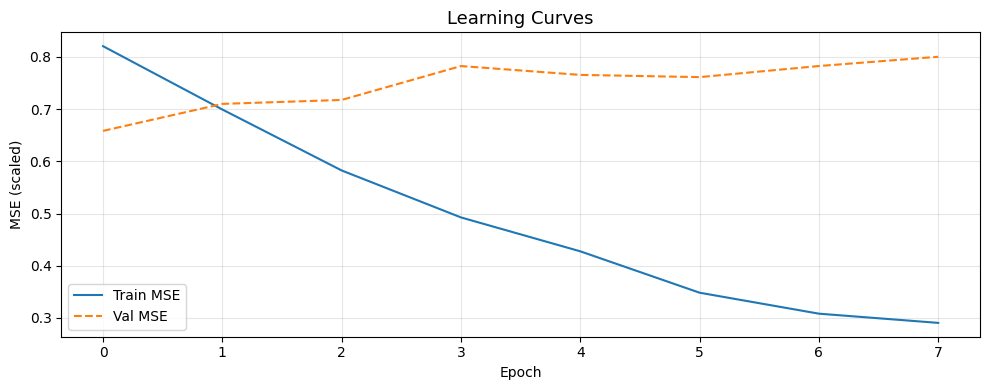

In [11]:
# ── Learning curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', linewidth=1.5)
ax.plot(val_losses,   label='Val MSE',   linewidth=1.5, linestyle='--')
ax.set_title('Learning Curves', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7  —  Evaluation (RMSE, MAE, R² per Horizon)

In [12]:
# ── Load best checkpoint before evaluating ────────────────────────────────────
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} "
      f"(val MSE = {checkpoint['val_loss']:.5f})")


def predict_all(loader) -> tuple[np.ndarray, np.ndarray]:
    """Return (all_preds, all_targets) in original (ppb) scale."""
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds_list.append(model(X_batch.to(DEVICE)).cpu().numpy())
            targets_list.append(y_batch.numpy())
    preds   = np.vstack(preds_list)    # (N, 3)
    targets = np.vstack(targets_list)  # (N, 3)
    # Inverse-transform each horizon column
    preds   = target_scaler.inverse_transform(preds)
    targets = target_scaler.inverse_transform(targets)
    return preds, targets


test_preds, test_targets = predict_all(test_loader)

print(f'\n{" Horizon ":^12} | {"RMSE (ppb)":^12} | {"MAE (ppb)":^12} | {"R²":^8}')
print('─' * 52)
metrics_dict = {}
for i, h in enumerate(HORIZONS):
    y_true = test_targets[:, i]
    y_pred = test_preds[:,  i]
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    metrics_dict[h] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'  +{h:>2}h ahead   | {rmse:^12.3f} | {mae:^12.3f} | {r2:^8.4f}')

Loaded best checkpoint from epoch 1 (val MSE = 0.65834)

  Horizon    |  RMSE (ppb)  |  MAE (ppb)   |    R²   
────────────────────────────────────────────────────
  + 4h ahead   |    10.678    |    6.359     |  0.0237 
  + 6h ahead   |    10.743    |    6.422     |  0.0117 
  +24h ahead   |    10.893    |    6.678     | -0.0161 


## 8  —  Save & Load Model

In [13]:
def save_model(model: nn.Module, path: str, extra_meta: dict | None = None):
    """
    Save a model checkpoint to disk.

    Parameters
    ----------
    model      : trained PyTorch model
    path       : file path ending in .pt or .pth
    extra_meta : optional dict of metadata to store alongside the weights
    """
    payload = {'model_state_dict': model.state_dict()}
    if extra_meta:
        payload.update(extra_meta)
    torch.save(payload, path)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f'Model saved → {path}  ({size_mb:.2f} MB)')


def load_model(path: str, device: torch.device = torch.device('cpu')) -> tuple[nn.Module, dict]:
    """
    Load a saved LSTM checkpoint from disk.

    Returns
    -------
    model      : PM25LSTMForecaster loaded with saved weights
    checkpoint : full checkpoint dict (includes scalers, feature names, etc.)
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    cfg = checkpoint['model_config']
    loaded_model = PM25LSTMForecaster(
        input_size  = cfg['input_size'],
        hidden_size = cfg['hidden_size'],
        num_layers  = cfg['num_layers'],
        dropout     = cfg['dropout'],
        n_horizons  = cfg['n_horizons'],
    ).to(device)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()
    print(f'Model loaded from → {path}')
    print(f'  Trained for {checkpoint["epoch"]} epoch(s),  '
          f'best val MSE = {checkpoint["val_loss"]:.5f}')
    print(f'  Features  : {checkpoint["feature_names"]}')
    print(f'  Horizons  : {checkpoint["horizons"]} hours ahead')
    return loaded_model, checkpoint


# ── Demo: save a named copy, then reload it ───────────────────────────────────
EXPORT_PATH = '../models/lstm_pm25_final.pt'
save_model(
    model, EXPORT_PATH,
    extra_meta={
        'model_config'       : {'input_size': N_FEATURES, 'hidden_size': 128,
                                'num_layers': 2, 'dropout': 0.2, 'n_horizons': len(HORIZONS)},
        'epoch'              : checkpoint['epoch'],
        'val_loss'           : checkpoint['val_loss'],
        'feature_names'      : ALL_FEATURES,
        'horizons'           : HORIZONS,
        'feat_scaler_mean'   : feat_scaler.mean_,
        'feat_scaler_scale'  : feat_scaler.scale_,
        'target_scaler_mean' : target_scaler.mean_,
        'target_scaler_scale': target_scaler.scale_,
    }
)

print('\n--- Reload demo ---')
reloaded_model, loaded_ckpt = load_model(EXPORT_PATH, device=DEVICE)

Model saved → ../models/lstm_pm25_final.pt  (0.82 MB)

--- Reload demo ---
Model loaded from → ../models/lstm_pm25_final.pt
  Trained for 1 epoch(s),  best val MSE = 0.65834
  Features  : ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Precip. Amount (mm)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
  Horizons  : [4, 6, 24] hours ahead


## 9  —  Visualisation

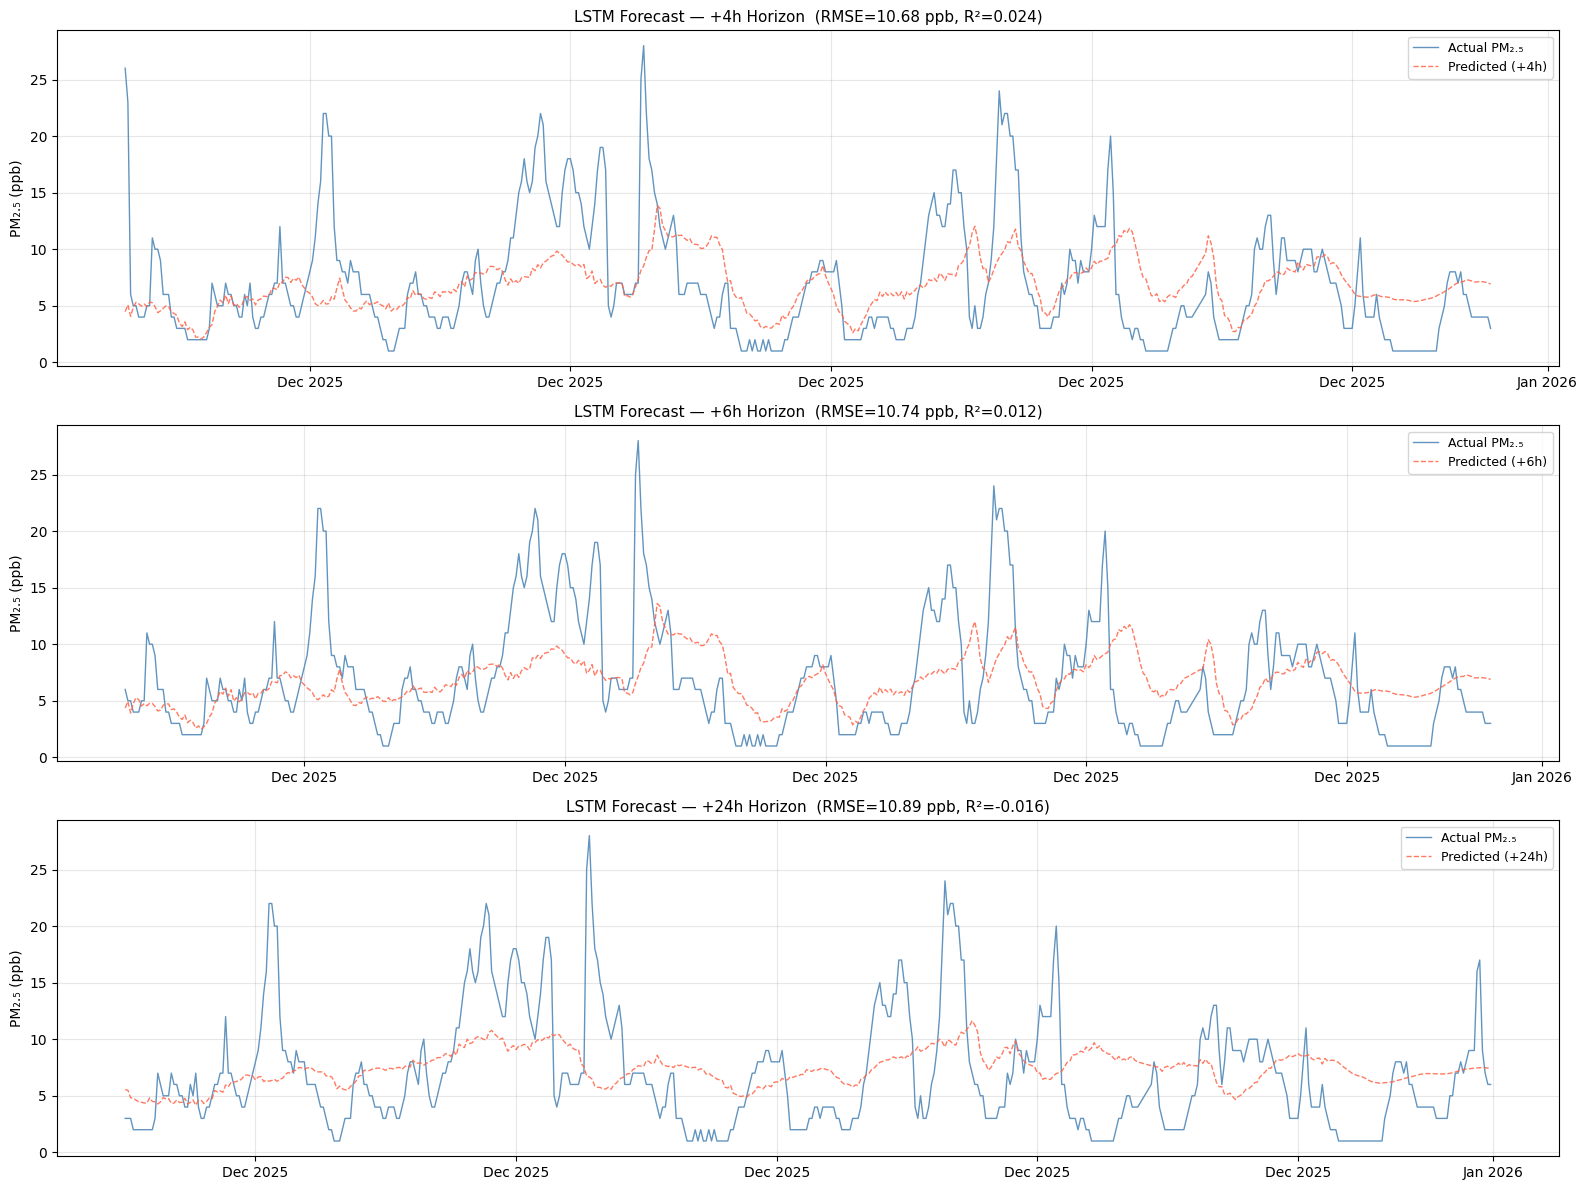

In [17]:
# ── Reconstruct test datetimes aligned to predictions ────────────────────────
# Each test sample starts at index (train_end + val_end_offset + idx)
# The target for horizon h is at position (lookback + h - 1) in test_df
test_df_reset = test_df.reset_index(drop=True)

# Number of valid samples in test set
n_test_samples = len(test_ds)

horizon_dates = {}
for i, h in enumerate(HORIZONS):
    # For sample idx, the target datetime is test_df row (idx + LOOKBACK + h - 1)
    date_indices = [idx + LOOKBACK + h - 1 for idx in range(n_test_samples)]
    horizon_dates[h] = test_df_reset.iloc[date_indices]['Datetime'].values

# ── Plot predictions vs actuals for each horizon ─────────────────────────────
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(16, 12), sharex=False)

PLOT_WINDOW = 500   # show only the last N test points for clarity

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    dates  = pd.to_datetime(horizon_dates[h])[-PLOT_WINDOW:]
    actual = test_targets[:, i][-PLOT_WINDOW:]
    pred   = test_preds[:,  i][-PLOT_WINDOW:]

    ax.plot(dates, actual, label='Actual PM₂.₅', linewidth=1.0,
            color='steelblue', alpha=0.85)
    ax.plot(dates, pred,   label=f'Predicted (+{h}h)', linewidth=1.0,
            color='tomato', linestyle='--', alpha=0.85)
    ax.set_title(f'LSTM Forecast — +{h}h Horizon  '
                 f'(RMSE={metrics_dict[h]["RMSE"]:.2f} ppb, '
                 f'R²={metrics_dict[h]["R2"]:.3f})',
                 fontsize=11)
    ax.set_ylabel('PM₂.₅ (ppb)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

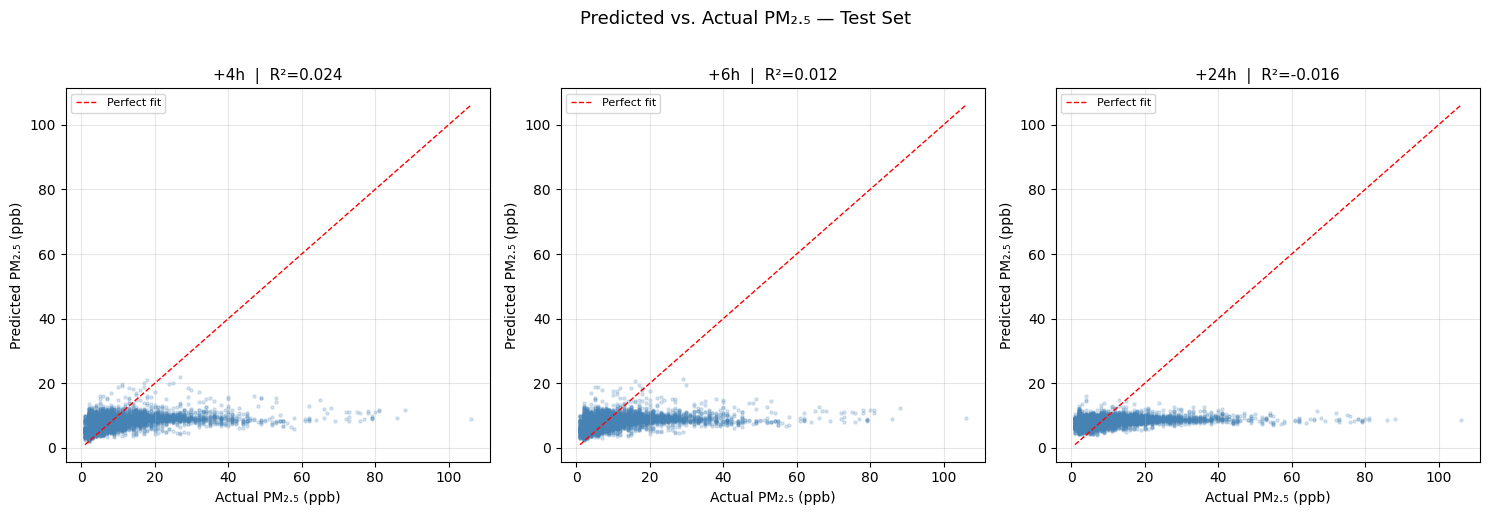

In [15]:
# ── Scatter: predicted vs. actual (one panel per horizon) ────────────────────
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 5))

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    y_true = test_targets[:, i]
    y_pred = test_preds[:,  i]
    ax.scatter(y_true, y_pred, alpha=0.2, s=5, color='steelblue')
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect fit')
    ax.set_title(f'+{h}h  |  R²={metrics_dict[h]["R2"]:.3f}', fontsize=11)
    ax.set_xlabel('Actual PM₂.₅ (ppb)')
    ax.set_ylabel('Predicted PM₂.₅ (ppb)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs. Actual PM₂.₅ — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Horizon': f'+{h}h', 'RMSE (ppb)': metrics_dict[h]['RMSE'],
     'MAE (ppb)': metrics_dict[h]['MAE'], 'R²': metrics_dict[h]['R2']}
    for h in HORIZONS
])
summary = summary.set_index('Horizon').round(4)
print('\n=== Final Test-Set Performance Summary ===')
display(summary)


=== Final Test-Set Performance Summary ===


,RMSE (ppb),MAE (ppb),R²
Horizon,,,
+4h,10.6777,6.3586,0.0237
+6h,10.7429,6.4217,0.0117
+24h,10.8928,6.6777,-0.0161
